<a href="https://colab.research.google.com/github/jjyjung/ai_semicon/blob/main/src/cnn/tf_keras_CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, utils, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import mnist

In [ ]:
# input image dimensions, output dimension
IMG_ROWS, IMG_COLS = 28, 28
NUM_CLASSES = 10

# the data, shuffled and split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# the data, shuffled and split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], IMG_ROWS, IMG_COLS, 1)  # 이미지 개수, 행, 열, 흑백(1채널)
x_test = x_test.reshape(x_test.shape[0], IMG_ROWS, IMG_COLS, 1)
input_shape = (IMG_ROWS, IMG_COLS, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = utils.to_categorical(y_train, NUM_CLASSES)
y_test = utils.to_categorical(y_test, NUM_CLASSES)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
# hyperparameters (실험변경 편의를 위하여 변수화)
batch_size = 100
epochs = 50
learning_rate = 0.001
dropout_rate = 0.5
patience = 10

In [ ]:
# model = Sequential()
# model.add(layers.Conv2D(16, (5, 5), strides=(1, 1), padding='same',
#                  activation='relu', input_shape=input_shape, name='conv1'))
# model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='pool1'))
# model.add(layers.Conv2D(32, (5, 5), strides=(1, 1), padding='same',
#                  activation='relu', name='conv2'))
# model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='pool2'))
# #model.add(layers.Dropout(dropout_rate))
# model.add(layers.Flatten())
# model.add(layers.Dense(32, activation='relu'))
# #model.add(layers.Dropout(dropout_rate))
# model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model = Sequential([
    layers.Input(shape=(IMG_ROWS, IMG_COLS, 1)),
    layers.Conv2D(16, (5, 5), padding='same', activation='relu', name='conv1'),
    layers.MaxPooling2D((2, 2), strides=(2, 2), name='pool1'),
    layers.Conv2D(32, (5, 5), padding='same', activation='relu', name='conv2'),
    layers.MaxPooling2D((2, 2), strides=(2, 2), name='pool2'),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(dropout_rate),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,786 (249.16 KB)

 Trainable params: 63,786 (249.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=['accuracy'],
)

# train model
early_stop = EarlyStopping(monitor = 'val_loss', patience = patience,
                          restore_best_weights=True)
hist = model.fit(x_train, y_train,
          batch_size = batch_size, epochs = epochs,
          validation_split = 0.2, callbacks = [early_stop],
          shuffle = True, verbose = 1)

Epoch 1/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7688 - loss: 0.6794 - val_accuracy: 0.9680 - val_loss: 0.1135
Epoch 2/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8852 - loss: 0.3323 - val_accuracy: 0.9772 - val_loss: 0.0740
Epoch 3/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9042 - loss: 0.2667 - val_accuracy: 0.9826 - val_loss: 0.0609
Epoch 4/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9163 - loss: 0.2320 - val_accuracy: 0.9825 - val_loss: 0.0605
Epoch 5/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9274 - loss: 0.2001 - val_accuracy: 0.9861 - val_loss: 0.0488
Epoch 6/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9362 - loss: 0.1745 - val_accuracy: 0.9872 - val_loss: 0.0485
Epoch 7/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9398 - loss: 0.1619 - val_accuracy: 0.9863 - val_loss: 0.0532
Epoch 8/50
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9463 - loss: 0.1466 - val_accuracy: 0.

"Epoch 3/10"의 의미는?

"480/480"의 의미는?

"2s 4ms/step"의 의미는?

"accuracy: 0.9899 - loss: 0.0301 - val_accuracy: 0.9883 - val_loss: 0.0400"의 의미는?

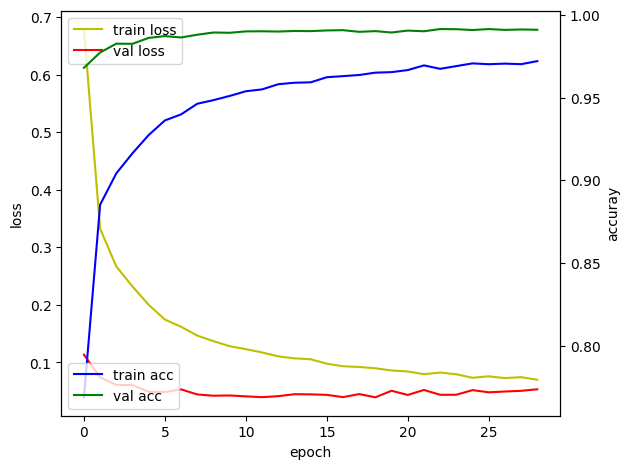

In [ ]:
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()
acc_ax = loss_ax.twinx()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax.plot(hist.history['accuracy'], 'b', label='train acc')
acc_ax.plot(hist.history['val_accuracy'], 'g', label='val acc')

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuray')
loss_ax.legend(loc='upper left')
acc_ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [ ]:
# evaluate model
score = model.evaluate(x_test, y_test, verbose = 1)
print('test_loss:', round(score[0], 4))
print('test_acc:', round(score[1], 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9911 - loss: 0.0277
test_loss: 0.0277
test_acc: 0.9911


In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')   # google drive를 google colab에 연결. 처음 실행 시, 인증 필요

ValueError: mount failed

In [ ]:
dir = "/content/gdrive/My Drive/Colab Notebooks/ai/CNN/"  ### [중요!!] Colab의 경우, 파일을 저장할 위치를 기록하시오.
# model.save(dir + "cnn_mnist.h5")
model.save(dir + "cnn_mnist.keras")